## Sales Analysis
This analysis is a comparision of sales performance between the Northeast territories of Maine and Maryland.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


After importing the csv files, I used .info() to gain insight into each dataset and .head() to preview the first few rows and better understand the structure and contents. 

In [2]:
store_sales = pd.read_csv("StoreSales.csv")
store_sales.info()
store_sales.head()

<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  str    
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  str    
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


In [3]:
store_detail = pd.read_csv("StoreDetail.csv")
store_detail.info()
store_detail.head()

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


In [4]:
products = pd.read_csv("Products.csv")
products.info()
products.head()

<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num       669 non-null    str  
 1   Product        669 non-null    str  
 2   CategoryID     669 non-null    int64
 3   SubcategoryID  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB


,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [5]:
product_categories = pd.read_csv("ProductCategories.csv")
product_categories.info()
product_categories.head()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB


,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [6]:
customer_list = pd.read_csv("Customer_List.csv", sep="|")
customer_list.info()
customer_list.head()

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   cust_id       521 non-null    int64
 1   date          521 non-null    str  
 2   time          521 non-null    str  
 3   name          521 non-null    str  
 4   email         521 non-null    str  
 5   phone         520 non-null    str  
 6   sms-opt-out   520 non-null    str  
dtypes: int64(1), str(6)
memory usage: 28.6 KB


,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


## Core Marketing Analysis

### Territory managers, state, store IDs, and store location

In [7]:
territory_detail = store_detail[                            # Filitering the assigned territories from store detail dataset using .isin,
    store_detail['State'].isin(['Maine', 'Maryland'])       # and from those territories, selecting the needed columns
][['Territory Manager', 'State', 'Store ID', 'Store Location']] # to create a dataframe containing territory details.
territory_detail

,Territory Manager,State,Store ID,Store Location
37,Erbayne Middleton,Maine,818,Bangor
38,Erbayne Middleton,Maine,819,Bar Harbor
39,Erbayne Middleton,Maine,820,Kennebunkport
40,Erbayne Middleton,Maine,821,Lewiston
41,Erbayne Middleton,Maine,822,Orono
42,Erbayne Middleton,Maine,823,South Portland
43,Shruti Reddy,Maryland,731,Annapolis
44,Shruti Reddy,Maryland,732,Back River
45,Shruti Reddy,Maryland,733,Baltimore
46,Shruti Reddy,Maryland,734,Germantown


### Monthly total revenue for Maine and Maryland (2022 - 2025)

In [8]:
store_info = pd.merge(store_sales, store_detail, on='Store ID') # Merging two datasets using their pk 

In [9]:
store_info = store_info[    # Filitering the assigned territories
    store_info['State'].isin(['Maine', 'Maryland'])] 

In [10]:
store_info['Month'] = pd.to_datetime( # Creating a month column in the dataframe
    store_info['Transaction Date']).dt.to_period('M')

In [11]:
monthly_revenue = store_info.groupby(['State', 'Month'])['Sale Amount'].sum() # Calculating monthy revenue by grouping the data
monthly_revenue                                                               # based on territory, month and sale ammount

State     Month  
Maine     2022-01     15700.31
          2022-02     21008.29
          2022-03     23173.23
          2022-04     20169.19
          2022-05     22631.11
                       ...    
Maryland  2025-08    311949.14
          2025-09    304304.79
          2025-10    359699.69
          2025-11    304194.50
          2025-12    332129.99
Name: Sale Amount, Length: 96, dtype: float64

### Sales performance rank for each store

In [12]:
store_performance = store_info.groupby(['State', 'Store ID', 'Store Location'] # Calculating total sales by store
                                      )[['Sale Amount']].sum().reset_index()

In [13]:
store_performance['Rank'] = store_performance['Sale Amount'].rank(ascending=False) # Creating rank column 

In [14]:
store_performance = store_performance.sort_values(by='Rank') # Sorting stores by rank

In [15]:
store_performance.head() # Displying the five top performer stores

,State,Store ID,Store Location,Sale Amount,Rank
11,Maryland,736,North Harford,8708119.00,1.0
9,Maryland,734,Germantown,584675.92,2.0
5,Maine,823,South Portland,332611.76,3.0
4,Maine,822,Orono,330505.47,4.0
2,Maine,820,Kennebunkport,321998.55,5.0


### Top customers in Maine and Maryland

In [16]:
customer_reward = pd.merge(customer_list, store_sales, left_on='cust_id', right_on='RewardsID') 
# Merging two datasets using left_on/right_on because they do not have the same column names

In [17]:
customer_reward = pd.merge(customer_reward, store_detail, on='Store ID')  # Merging the third dataset inorder to include State in the output

In [18]:
customer_reward = customer_reward[customer_reward['State'].isin(['Maine', 'Maryland'])] # Filitering data by state

In [19]:
top_customers = customer_reward.groupby(['State', 'Store ID', 'name'] # Grouping by state, store ID, customer name, then calculating  
                )[['Sale Amount']].sum().reset_index()                #  the sale amount

In [20]:
top_customers['Rank'] = top_customers['Sale Amount'].rank(ascending=False) # Creating rank column

In [21]:
top_customers = top_customers.sort_values(by='Rank') # Sorting the top customers by rank

In [22]:
top_customers[top_customers['State'] == 'Maine'].head() # Top 5 spending customers in Maine

,State,Store ID,name,Sale Amount,Rank
1008,Maine,823,James Hurley,2427.58,127.0
1066,Maine,823,Philip Banks,2263.02,150.0
260,Maine,819,Jeff Winger,1981.04,201.0
1023,Maine,823,Karen Walker,1763.70,236.0
450,Maine,820,Jenny Piccalo,1763.70,236.0


In [23]:
top_customers[top_customers['State'] == 'Maryland'].head() # Top 5 spending customers in Maryland

,State,Store ID,name,Sale Amount,Rank
2283,Maryland,736,Cole Brown,6560.14,1.0
2219,Maryland,736,Avon Barksdale,6133.92,2.0
2317,Maryland,736,Donna Hayward,5121.79,3.0
2685,Maryland,736,Wednesday Addams,4962.10,4.0
2431,Maryland,736,Joe Keene Jr.,4941.90,5.0


### Transactions per month by product category and  total sales revenue per month by category

In [24]:
sold_products = pd.merge(store_sales, products, on='Prod Num') # Merging store_sales and products datasets

In [25]:
categories = pd.merge(sold_products, product_categories, on='CategoryID') # Merging the combined dataset with product_categories


In [26]:
categories = pd.merge(categories, store_detail, on='Store ID') # Merging the combined dataset with store_detail dataset

In [27]:
categories['Transaction Date'] = pd.to_datetime(categories['Transaction Date']) # Converting Transaction Date column to datetime format

In [28]:
categories['Month'] = categories['Transaction Date'].dt.to_period('M') # Creating a month column from transaction date

In [29]:
territories = categories[categories['State'].isin(['Maine', 'Maryland'])] # Filitering data to assigned territories

In [31]:
transactions = territories.groupby(['Month', 'Category'])['Prod Num'].count().reset_index(name='Transaction Count')
# Grouping transactions by month and category to calculate transaction counts

In [32]:
revenue = territories.groupby(['Month', 'Category'] # Grouping revenue by month and category to calculate revenue
)[['Sale Amount']].sum().reset_index()

In [33]:
transactions.head() # The first five transaction 


,Month,Category,Transaction Count
0,2022-01,Apparel and Merchandise,2320
1,2022-01,Art Supplies,3234
2,2022-01,Books (General),1228
3,2022-01,Stationery and Supplies,3036
4,2022-01,Technology & Accessories,2254


In [34]:
transactions.sort_values(by='Transaction Count', ascending=False).head() 
# Top five category-month combinations with the highest transaction counts

,Month,Category,Transaction Count
237,2025-04,Stationery and Supplies,7678
243,2025-05,Stationery and Supplies,7502
219,2025-01,Stationery and Supplies,7337
249,2025-06,Stationery and Supplies,6743
273,2025-10,Stationery and Supplies,6666


In [35]:
transactions.sort_values(by='Transaction Count', ascending=True).head()

,Month,Category,Transaction Count
14,2022-03,Books (General),1000
20,2022-04,Books (General),1016
62,2022-11,Books (General),1036
50,2022-09,Books (General),1044
26,2022-05,Books (General),1116


In [39]:
category_com = transactions.groupby('Category')['Transaction Count'].sum().reset_index()

Text(0, 0.5, 'Product Categories')

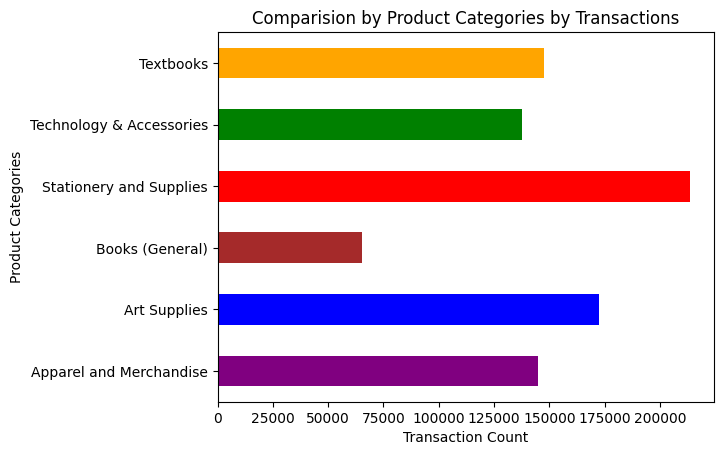

In [40]:
category_com.plot(kind='barh', 
                  x='Category',
                  y='Transaction Count',
                  title='Comparision by Product Categories by Transactions',
                  color=['purple', 'blue', 'brown', 'red', 'green', 'orange'],
                  legend=False
                  
)
plt.xlabel('Transaction Count')
plt.ylabel('Product Categories')

The chart above compares categories by transaction for both territories. As shown above, Stationery and Supplies have the highest transactions of all and the implication is that those items are affordable and often purchased. Books(General are the least transaction counts

In [41]:
revenue.sort_values(by='Sale Amount', ascending=False).head()

,Month,Category,Sale Amount
274,2025-10,Technology & Accessories,2379477.52
286,2025-12,Technology & Accessories,2114587.44
256,2025-07,Technology & Accessories,1956662.05
262,2025-08,Technology & Accessories,1938972.70
280,2025-11,Technology & Accessories,1934173.01


In [ ]:
revenue.sort_values(by='Sale Amount', ascending=True).head()

In [ ]:
territories['Quarter'] = territories['Transaction Date'].dt.to_period('Q')

In [ ]:
quarterly_revenue = territories.groupby('Quarter', as_index=False)['Sale Amount'].sum()

In [ ]:
quarterly_revenue.plot(kind='line',
                 x='Quarter',
                 y='Sale Amount',
                 figsize=(10,6),
                 title='Quarterly Revenue Trend (2022-2025)',
                 marker='*',
                 markersize=8,
                 linewidth=3,
                 color='purple',
                 grid=True,
                 legend=False
                    
                 
)
plt.xlabel('Quarter')
plt.ylabel('Revenue ($)')
plt.ticklabel_format(style='plain', axis='y')